# Grid Segmentation Pipeline for a Specified PDF Page（指定 PDF 单页处理版）

这份 notebook 以 **单个 PDF 的指定页** 为处理对象，保留此前版本的主流程：

1. `Rc / Rg / ROI / deskew / 规则线检测`
2. 根据识别到的横线和竖线，将该页切分成一个个方块图片
3. 保存 overlay、切分结果、索引 CSV

与全文批处理版不同的是：

- **不再处理 formal/ 下所有 PDF**
- 只对你指定的 **某一个 PDF 文件 + 某一页** 进行渲染和处理
- 其余功能尽量保持一致


In [1]:
%matplotlib inline
import os
import math
import gc
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# 中文显示（如果环境里没有 mlp_chinese，也不会报错）
try:
    import mlp_chinese
    mlp_chinese.setup_chinese()
except Exception:
    pass

np.set_printoptions(suppress=True, precision=3)

[mpl_chinese] 使用字体: Noto Sans CJK JP


## 工具函数

In [2]:
def normalize01(arr):
    arr = np.asarray(arr, dtype=np.float32)
    if arr.size == 0:
        return arr.astype(np.float32)
    mn, mx = float(arr.min()), float(arr.max())
    if mx - mn < 1e-6:
        return np.zeros_like(arr, dtype=np.float32)
    return (arr - mn) / (mx - mn)

def smooth_curve(arr, win):
    arr = np.asarray(arr, dtype=np.float32)
    win = int(max(5, win))
    if win % 2 == 0:
        win += 1
    kernel = np.ones(win, dtype=np.float32) / win
    return np.convolve(arr, kernel, mode='same')

def smooth_1d(arr, ksize=31):
    arr = np.asarray(arr, dtype=np.float32)
    if ksize % 2 == 0:
        ksize += 1
    kernel = np.ones(ksize, dtype=np.float32) / ksize
    return np.convolve(arr, kernel, mode='same')

def largest_true_interval(mask_1d):
    best = None
    start = None
    for i, v in enumerate(mask_1d):
        if v and start is None:
            start = i
        if (not v) and start is not None:
            cur = (start, i)
            if best is None or (cur[1] - cur[0]) > (best[1] - best[0]):
                best = cur
            start = None
    if start is not None:
        cur = (start, len(mask_1d))
        if best is None or (cur[1] - cur[0]) > (best[1] - best[0]):
            best = cur
    return best

def refine_peaks(raw_signal, peaks, search_radius=4):
    refined = []
    n = len(raw_signal)
    for p in peaks:
        lo = max(0, int(p - search_radius))
        hi = min(n, int(p + search_radius + 1))
        if hi <= lo:
            continue
        local = raw_signal[lo:hi]
        rp = lo + int(np.argmax(local))
        refined.append(rp)
    if len(refined) == 0:
        return np.array([], dtype=int)
    return np.array(sorted(set(refined)), dtype=int)

def merge_close_peaks(peaks, min_gap):
    peaks = np.asarray(peaks, dtype=int)
    if len(peaks) == 0:
        return peaks
    peaks = np.array(sorted(peaks), dtype=int)
    merged = [int(peaks[0])]
    for p in peaks[1:]:
        if p - merged[-1] < min_gap:
            merged[-1] = int(round((merged[-1] + p) / 2))
        else:
            merged.append(int(p))
    return np.array(merged, dtype=int)

def regularize_peaks(peaks, period_est, max_len, fill_missing=True):
    peaks = np.asarray(peaks, dtype=int)
    if len(peaks) == 0:
        return peaks
    if period_est is None or period_est <= 0:
        return np.array(sorted(set(peaks)), dtype=int)

    peaks = merge_close_peaks(peaks, min_gap=max(3, int(period_est * 0.45)))
    peaks = list(peaks)

    if (not fill_missing) or len(peaks) <= 1:
        return np.array(sorted(set([p for p in peaks if 0 <= p < max_len])), dtype=int)

    out = [peaks[0]]
    for a, b in zip(peaks[:-1], peaks[1:]):
        gap = b - a
        if gap <= period_est * 1.6:
            out.append(b)
        else:
            n_seg = max(2, int(round(gap / period_est)))
            step = gap / n_seg
            for k in range(1, n_seg):
                out.append(int(round(a + k * step)))
            out.append(b)
    return np.array(sorted(set([p for p in out if 0 <= p < max_len])), dtype=int)

def detect_grid_peaks(signal, period_est, fill_missing=True, conservative=False):
    n = len(signal)
    if period_est is None or period_est <= 0:
        period_est = max(20, n // 15)

    sm = smooth_curve(signal, max(5, int(period_est * (0.18 if not conservative else 0.22))))
    sm_norm = normalize01(sm)

    if conservative:
        min_dist = max(6, int(period_est * 0.78))
        prom = max(0.04, float(np.quantile(sm_norm[sm_norm > 0], 0.70) * 0.22)) if np.any(sm_norm > 0) else 0.05
    else:
        min_dist = max(5, int(period_est * 0.55))
        prom = max(0.03, float(np.quantile(sm_norm[sm_norm > 0], 0.65) * 0.18)) if np.any(sm_norm > 0) else 0.05

    peaks, _ = find_peaks(sm_norm, distance=min_dist, prominence=prom)

    if len(peaks) > 0:
        vals = sm_norm[peaks]
        if conservative:
            h_thr = max(0.12, float(np.quantile(vals, 0.35)))
        else:
            h_thr = max(0.10, float(np.quantile(vals, 0.20)))
        peaks = peaks[vals >= h_thr]

    peaks = refine_peaks(signal, peaks, search_radius=max(3, int(period_est * 0.10)))
    peaks = regularize_peaks(peaks, period_est=period_est, max_len=n,
                             fill_missing=(fill_missing and (not conservative)))
    return sm_norm, peaks

def make_row_band_mask(height, peaks_local, band_half=1):
    mask = np.zeros(height, dtype=bool)
    for p in peaks_local:
        lo = max(0, int(p - band_half))
        hi = min(height, int(p + band_half + 1))
        mask[lo:hi] = True
    return mask

def draw_full_lines(shape, h_peaks=None, v_peaks=None, roi=None, thickness=1):
    H, W = shape
    out = np.zeros((H, W), dtype=np.uint8)
    if roi is None:
        x0, x1, y0, y1 = 0, W - 1, 0, H - 1
    else:
        x0, x1, y0, y1 = roi

    if h_peaks is not None:
        for y in h_peaks:
            cv2.line(out, (x0, int(y)), (x1, int(y)), 255, thickness)
    if v_peaks is not None:
        for x in v_peaks:
            cv2.line(out, (int(x), y0), (int(x), y1), 255, thickness)
    return out

def sample_signal_at_positions(signal, positions):
    if len(positions) == 0:
        return np.array([], dtype=np.float32)
    pos = np.clip(np.round(np.asarray(positions)).astype(int), 0, len(signal)-1)
    return np.asarray(signal, dtype=np.float32)[pos]

def fit_regular_lattice_from_signal(signal, period_est=None, allow_double=True,
                                    min_lines=4, max_lines=80):
    """
    给定 1D 周期信号，拟合等间距晶格 x_k = x0 + k*s
    返回：best_positions_local, best_spacing, debug
    """
    signal = normalize01(np.asarray(signal, dtype=np.float32))
    n = len(signal)

    if period_est is None or period_est <= 0:
        period_est = max(12.0, n / 18.0)

    sm_loose = smooth_curve(signal, max(5, int(period_est * 0.14)))
    min_dist_loose = max(4, int(period_est * 0.35))
    prom_loose = max(0.02, float(np.quantile(sm_loose[sm_loose > 0], 0.60) * 0.08)) if np.any(sm_loose > 0) else 0.03
    cand_peaks, _ = find_peaks(sm_loose, distance=min_dist_loose, prominence=prom_loose)
    cand_strength = sm_loose[cand_peaks] if len(cand_peaks) > 0 else np.array([], dtype=np.float32)

    spacing_hyps = []
    for base in ([period_est, period_est * 2.0] if allow_double else [period_est]):
        for fac in [0.85, 0.92, 1.00, 1.08, 1.16]:
            s = base * fac
            if 6 <= s <= n / 2:
                spacing_hyps.append(float(s))

    if len(cand_peaks) >= 4:
        diffs = np.diff(cand_peaks)
        med = float(np.median(diffs))
        for base in [med, med * 2.0]:
            for fac in [0.90, 1.00, 1.10]:
                s = base * fac
                if 6 <= s <= n / 2:
                    spacing_hyps.append(float(s))

    spacing_hyps = sorted(set([round(s, 2) for s in spacing_hyps]))

    best_score = -1e18
    best_positions = np.array([], dtype=int)
    best_spacing = float(period_est)
    best_dbg = {}

    for s in spacing_hyps:
        s_int = max(1, int(round(s)))
        sigma = max(1.5, 0.12 * s)

        for phi in range(s_int):
            positions = np.arange(phi, n, s, dtype=np.float32)
            if len(positions) < min_lines or len(positions) > max_lines:
                continue

            sampled = sample_signal_at_positions(signal, positions)
            score = 1.0 * float(np.mean(sampled)) + 0.4 * float(np.percentile(sampled, 80))

            if len(cand_peaks) > 0:
                d = np.min(np.abs(cand_peaks[:, None] - positions[None, :]), axis=1)
                align = np.exp(-(d ** 2) / (2 * sigma ** 2))
                score += 0.55 * float(np.average(align, weights=cand_strength + 1e-4))

            line_count = len(positions)
            if line_count < min_lines or line_count > max_lines:
                score -= 10

            if score > best_score:
                best_score = score
                best_positions = np.round(positions).astype(int)
                best_spacing = float(s)
                best_dbg = {
                    "phi": phi,
                    "spacing": float(s),
                    "score": float(score),
                    "cand_peaks": cand_peaks,
                    "sm_loose": sm_loose,
                }

    best_positions = np.array(sorted(set([p for p in best_positions if 0 <= p < n])), dtype=int)
    return best_positions, best_spacing, best_dbg

def robust_peak_spacing(peaks, fallback=None):
    peaks = np.asarray(peaks, dtype=int)
    if len(peaks) >= 2:
        return float(np.median(np.diff(peaks)))
    return float(fallback) if fallback is not None else None

def auto_select_primary_grid_peaks(peaks_all, signal_local, period_ref=None, dense_threshold_count=18):
    peaks_all = np.array(sorted(set(np.asarray(peaks_all, dtype=int))), dtype=int)
    if len(peaks_all) == 0:
        return peaks_all, {"used_half": False, "reason": "empty"}

    spacing_all = robust_peak_spacing(peaks_all, fallback=period_ref)
    dense = False
    reason = []
    if len(peaks_all) >= dense_threshold_count:
        dense = True
        reason.append('count')
    if period_ref is not None and spacing_all is not None and spacing_all < 0.78 * period_ref:
        dense = True
        reason.append('spacing')

    def score_subset(peaks):
        peaks = np.asarray(peaks, dtype=int)
        if len(peaks) == 0:
            return -1e9
        vals = sample_signal_at_positions(signal_local, peaks)
        s = 1.0 * float(np.mean(vals)) + 0.25 * float(np.percentile(vals, 80))
        if len(peaks) >= 3:
            d = np.diff(peaks).astype(np.float32)
            cv = float(np.std(d) / (np.mean(d) + 1e-6))
            s += 0.25 * (1.0 - cv)
        return s

    if dense:
        even = peaks_all[::2]
        odd = peaks_all[1::2]
        selected = even if score_subset(even) >= score_subset(odd) else odd
        used_half = True
    else:
        selected = peaks_all
        used_half = False

    dbg = {
        "used_half": used_half,
        "reason": '+'.join(reason) if reason else 'keep_all',
        "peaks_all": peaks_all,
        "spacing_all": spacing_all,
    }
    return np.asarray(selected, dtype=int), dbg

def extend_lattice_to_bounds(peaks, signal_local, spacing, edge_frac=0.60, support_frac=0.18):
    peaks = np.array(sorted(set(np.asarray(peaks, dtype=int))), dtype=int)
    if len(peaks) == 0 or spacing is None or spacing <= 0:
        return peaks

    n = len(signal_local)
    spacing = float(spacing)
    support_radius = max(1, int(round(spacing * 0.18)))
    sig_max = float(np.max(signal_local)) if len(signal_local) > 0 else 0.0
    thr = support_frac * sig_max

    def local_support(pos):
        pos = int(np.clip(pos, 0, n - 1))
        lo = max(0, pos - support_radius)
        hi = min(n, pos + support_radius + 1)
        if hi <= lo:
            return 0.0
        return float(np.max(signal_local[lo:hi]))

    if peaks[0] > edge_frac * spacing:
        cand = int(round(peaks[0] - spacing))
        if cand >= 0:
            if local_support(cand) >= thr:
                peaks = np.r_[cand, peaks]
        else:
            if local_support(0) >= thr:
                peaks = np.r_[0, peaks]

    if (n - 1 - peaks[-1]) > edge_frac * spacing:
        cand = int(round(peaks[-1] + spacing))
        if cand < n:
            if local_support(cand) >= thr:
                peaks = np.r_[peaks, cand]
        else:
            if local_support(n - 1) >= thr:
                peaks = np.r_[peaks, n - 1]

    peaks = merge_close_peaks(peaks, min_gap=max(3, int(spacing * 0.55)))
    return np.asarray(peaks, dtype=int)

def select_half_peaks(col_peaks, signal_local=None, mode="half_auto"):
    """
    手动减半模式：
      - all
      - half_even
      - half_odd
      - half_auto
    """
    col_peaks = np.array(col_peaks, dtype=int)
    if len(col_peaks) == 0 or mode == "all":
        return col_peaks

    if mode == "half_even":
        return col_peaks[::2]

    if mode == "half_odd":
        return col_peaks[1::2]

    if mode == "half_auto":
        even = col_peaks[::2]
        odd = col_peaks[1::2]

        def score(peaks):
            if len(peaks) == 0:
                return -1.0
            if signal_local is None or len(signal_local) == 0:
                return float(len(peaks))
            vals = []
            n = len(signal_local)
            for x in peaks:
                if 0 <= x < n:
                    x0 = max(0, x - 1)
                    x1 = min(n, x + 2)
                    vals.append(float(np.mean(signal_local[x0:x1])))
            return float(np.mean(vals)) if len(vals) > 0 else -1.0

        return even if score(even) >= score(odd) else odd

    raise ValueError(f"未知 mode={mode}")

def _longest_true_run_ratio(mask_1d):
    mask_1d = np.asarray(mask_1d, dtype=bool)
    if mask_1d.size == 0:
        return 0.0
    best = 0
    cur = 0
    for v in mask_1d:
        if v:
            cur += 1
            best = max(best, cur)
        else:
            cur = 0
    return float(best) / float(len(mask_1d) + 1e-6)

def select_interleaved_phase(peaks_all, signal_local, vert_map=None):
    """
    交错双相位选择：
    假设 peaks_all 中实线峰与虚线峰交错出现，
    比较偶数组与奇数组的整体强度，选择更像实线边框的一组。
    """
    peaks_all = np.array(sorted(set(np.asarray(peaks_all, dtype=int))), dtype=int)
    if len(peaks_all) <= 2:
        return peaks_all, {"method": "too_few_peaks"}

    even = peaks_all[::2]
    odd = peaks_all[1::2]
    sig = normalize01(np.asarray(signal_local, dtype=np.float32))

    def group_strength(group):
        if len(group) == 0:
            return -1.0
        vals = np.array([sig[int(np.clip(x, 0, len(sig)-1))] for x in group], dtype=np.float32)
        # 核心判据：用低分位数而不是均值，避免少数异常强峰影响
        return float(np.quantile(vals, 0.20))

    def group_continuity(group):
        if vert_map is None or len(group) == 0:
            return 0.0
        vbin = (vert_map > 0).astype(np.uint8)
        W = vbin.shape[1]
        conts = []
        for x in group:
            x = int(np.clip(x, 0, W - 1))
            x0 = max(0, x - 1)
            x1 = min(W, x + 2)
            strip = vbin[:, x0:x1]
            row_has = (strip.mean(axis=1) >= 0.34).astype(np.uint8)

            best = 0
            cur = 0
            for v in row_has:
                if v:
                    cur += 1
                    best = max(best, cur)
                else:
                    cur = 0
            conts.append(best / max(1, len(row_has)))
        return float(np.median(conts))

    s_even = group_strength(even)
    s_odd  = group_strength(odd)
    c_even = group_continuity(even)
    c_odd  = group_continuity(odd)

    score_even = 0.80 * s_even + 0.20 * c_even
    score_odd  = 0.80 * s_odd  + 0.20 * c_odd

    if score_even >= score_odd:
        final = even
        chosen = "even"
    else:
        final = odd
        chosen = "odd"

    dbg = {
        "method": "interleaved_phase_select",
        "even": even,
        "odd": odd,
        "score_even": score_even,
        "score_odd": score_odd,
        "strength_even": s_even,
        "strength_odd": s_odd,
        "cont_even": c_even,
        "cont_odd": c_odd,
        "chosen": chosen,
    }
    return final, dbg

def choose_vertical_peaks(peaks_all, signal_local, vert_map=None, mode="all"):
    """
    统一竖线选择入口。
    支持：
      - all
      - half_auto
      - half_even
      - half_odd
      - interleaved_phase
    """
    peaks_all = np.array(sorted(set(np.asarray(peaks_all, dtype=int))), dtype=int)
    if mode == "interleaved_phase":
        return select_interleaved_phase(peaks_all, signal_local, vert_map)
    elif mode in ("all", "half_auto", "half_even", "half_odd"):
        return select_half_peaks(peaks_all, signal_local=signal_local, mode=mode), {
            "method": mode
        }
    else:
        raise ValueError(f"未知 vertical mode: {mode}")

def choose_batch_vertical_mode(raw_count, median_count, base_mode="all", ratio_threshold=1.75, min_extra=4):
    """
    批次自适应模式选择：
    如果某页的 raw 竖线候选数显著高于整批中位数，
    说明更可能混入了交错虚线峰，启用 interleaved_phase；
    否则保持 base_mode。
    """
    raw_count = int(raw_count)
    median_count = float(median_count)
    trigger_threshold = max(int(math.ceil(median_count * ratio_threshold)), int(math.ceil(median_count)) + int(min_extra))
    use_interleaved = raw_count >= trigger_threshold
    chosen = "interleaved_phase" if use_interleaved else base_mode
    dbg = {
        "raw_count": raw_count,
        "median_count": median_count,
        "ratio_threshold": ratio_threshold,
        "min_extra": min_extra,
        "trigger_threshold": trigger_threshold,
        "use_interleaved": use_interleaved,
        "chosen_mode": chosen,
    }
    return chosen, dbg

def draw_overlay(img_rgb, h_lines_raw, v_lines_raw):
    vis = img_rgb.copy()
    for x1, y1, x2, y2 in h_lines_raw:
        cv2.line(vis, (x1, y1), (x2, y2), (255, 0, 0), 2)
    for x1, y1, x2, y2 in v_lines_raw:
        cv2.line(vis, (x1, y1), (x2, y2), (0, 0, 255), 2)
    return vis

def rotate_gray_same_canvas(img, angle_deg, border_value=0):
    h, w = img.shape[:2]
    center = (w / 2.0, h / 2.0)
    M = cv2.getRotationMatrix2D(center, angle_deg, 1.0)
    return cv2.warpAffine(
        img, M, (w, h),
        flags=cv2.INTER_CUBIC,
        borderMode=cv2.BORDER_CONSTANT,
        borderValue=border_value
    )

def horizontal_peakiness_score(gray_like):
    arr = gray_like.astype(np.float32)
    row = arr.mean(axis=1)
    row_s = smooth_curve(row, 9)
    row_n = normalize01(row_s)
    score = float(np.percentile(row_n, 99) - np.percentile(row_n, 75))
    score += 0.35 * float(np.std(row_n))
    return score


## 可选：每页小角度 deskew

In [3]:

def estimate_small_rotation_angle_from_rc(Rc, max_abs_angle=6.0, coarse_step=0.5, fine_step=0.1):
    """
    利用 Rc 的水平结构峰锐度做小角度 deskew。
    先粗搜，再细搜。返回“应作用于原图”的旋转角度。
    """
    Rc_u8 = (normalize01(Rc) * 255).astype(np.uint8)

    best_ang = 0.0
    best_score = -1e18

    # coarse search
    for ang in np.arange(-max_abs_angle, max_abs_angle + 1e-6, coarse_step):
        rot = rotate_gray_same_canvas(Rc_u8, ang, border_value=0)
        score = horizontal_peakiness_score(rot)
        if score > best_score:
            best_score = score
            best_ang = float(ang)

    # fine search around coarse optimum
    fine_best = best_ang
    fine_score = best_score
    lo = max(-max_abs_angle, best_ang - coarse_step)
    hi = min(max_abs_angle, best_ang + coarse_step)
    for ang in np.arange(lo, hi + 1e-6, fine_step):
        rot = rotate_gray_same_canvas(Rc_u8, ang, border_value=0)
        score = horizontal_peakiness_score(rot)
        if score > fine_score:
            fine_score = score
            fine_best = float(ang)

    return fine_best

def rotate_image_keep_canvas(img, angle_deg, border_value=(255,255,255)):
    h, w = img.shape[:2]
    center = (w / 2, h / 2)
    M = cv2.getRotationMatrix2D(center, angle_deg, 1.0)

    cos = abs(M[0, 0]); sin = abs(M[0, 1])
    new_w = int(h * sin + w * cos)
    new_h = int(h * cos + w * sin)

    M[0, 2] += new_w / 2 - center[0]
    M[1, 2] += new_h / 2 - center[1]

    return cv2.warpAffine(
        img, M, (new_w, new_h),
        flags=cv2.INTER_CUBIC,
        borderMode=cv2.BORDER_CONSTANT,
        borderValue=border_value
    )


## 封装后的 exact 版本函数

In [4]:

def run_cell4_rc_exact(img_bgr, show=False):
    img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    h_ch, s_ch, v_ch = img_hsv[:, :, 0], img_hsv[:, :, 1], img_hsv[:, :, 2]

    H_LOW, H_HIGH = 85, 130
    h_mask = (h_ch >= H_LOW) & (h_ch <= H_HIGH)

    s_in_hue = s_ch[h_mask]
    if len(s_in_hue) > 100:
        p20, p35, p50, p70 = np.percentile(s_in_hue, [20, 35, 50, 70])
        S_LOW = int(np.clip(p20 * 0.9, 8, 30))
        S_STRONG = int(np.clip(p70, 35, 90))
    else:
        S_LOW = 12
        S_STRONG = 45

    color_mask_loose = (h_mask & (s_ch >= S_LOW)).astype(np.uint8) * 255
    color_mask_strong = (h_mask & (s_ch >= S_STRONG)).astype(np.uint8) * 255

    loose_f = (color_mask_loose > 0).astype(np.float32)
    strong_f = (color_mask_strong > 0).astype(np.float32)

    local_density_loose = cv2.boxFilter(loose_f, ddepth=-1, ksize=(21, 21), normalize=True)
    local_density_strong = cv2.boxFilter(strong_f, ddepth=-1, ksize=(15, 15), normalize=True)

    block_seed = (
        (strong_f > 0) &
        ((local_density_loose >= 0.12) | (local_density_strong >= 0.08))
    ).astype(np.uint8) * 255

    block_seed = cv2.morphologyEx(
        block_seed, cv2.MORPH_CLOSE,
        cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
    )

    num_labels, labels_arr, stats, _ = cv2.connectedComponentsWithStats(
        (block_seed > 0).astype(np.uint8), 8
    )

    block_mask = np.zeros_like(color_mask_loose)
    for i in range(1, num_labels):
        x, y, w, h, area = stats[i]
        aspect = max(w / (h + 1e-6), h / (w + 1e-6))
        keep_block = (area >= 80 and min(w, h) >= 6 and aspect <= 8.0)
        if keep_block:
            block_mask[labels_arr == i] = 255

    block_mask = cv2.dilate(
        block_mask,
        cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3)),
        iterations=1
    )

    keep_mask = cv2.subtract(color_mask_loose, block_mask)

    line_kernel_h = cv2.getStructuringElement(cv2.MORPH_RECT, (9, 1))
    line_kernel_v = cv2.getStructuringElement(cv2.MORPH_RECT, (1, 9))
    resp_h = cv2.morphologyEx(keep_mask, cv2.MORPH_OPEN, line_kernel_h)
    resp_v = cv2.morphologyEx(keep_mask, cv2.MORPH_OPEN, line_kernel_v)
    line_resp = np.maximum(resp_h, resp_v).astype(np.float32) / 255.0

    S_norm = s_ch.astype(np.float32) / 255.0
    Rc_soft = np.zeros_like(S_norm, dtype=np.float32)
    Rc_soft[h_mask] = 0.25 + 0.75 * S_norm[h_mask]
    Rc_soft = Rc_soft * (keep_mask > 0).astype(np.float32)

    Rc = np.maximum(0.65 * line_resp, 0.35 * Rc_soft)
    Rc = Rc / Rc.max() if Rc.max() > 0 else Rc

    dbg = {
        "img_hsv": img_hsv,
        "h_mask": h_mask,
        "color_mask_loose": color_mask_loose,
        "color_mask_strong": color_mask_strong,
        "block_seed": block_seed,
        "block_mask": block_mask,
        "keep_mask": keep_mask,
        "line_resp": line_resp,
        "S_LOW": S_LOW,
        "S_STRONG": S_STRONG,
    }

    if show:
        fig, axes = plt.subplots(1, 7, figsize=(32, 6))
        axes[0].imshow(h_mask, cmap='gray');              axes[0].set_title(f"H in [{H_LOW}, {H_HIGH}]")
        axes[1].imshow(color_mask_loose, cmap='gray');   axes[1].set_title(f"H + S>={S_LOW} (宽松)")
        axes[2].imshow(color_mask_strong, cmap='gray');  axes[2].set_title(f"H + S>={S_STRONG} (强蓝)")
        axes[3].imshow(block_seed, cmap='gray');         axes[3].set_title("block_seed")
        axes[4].imshow(block_mask, cmap='gray');         axes[4].set_title("block_mask")
        axes[5].imshow(keep_mask, cmap='gray');          axes[5].set_title("保留组件")
        axes[6].imshow(Rc, cmap='hot');                  axes[6].set_title("Rc")
        for ax in axes:
            ax.axis("off")
        plt.tight_layout()
        plt.show()

    return Rc, dbg


In [5]:
def run_cell5_rg_exact(img_bgr, show=False):
    img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(16, 16))
    img_clahe = clahe.apply(img_gray)

    sobel_x = cv2.Sobel(img_clahe, cv2.CV_32F, 1, 0, ksize=3)
    sobel_y = cv2.Sobel(img_clahe, cv2.CV_32F, 0, 1, ksize=3)
    abs_gx = np.abs(sobel_x)
    abs_gy = np.abs(sobel_y)

    eps = 1e-6
    h_line_resp = abs_gy / (abs_gx + abs_gy + eps) * abs_gy
    v_line_resp = abs_gx / (abs_gx + abs_gy + eps) * abs_gx
    Rg_raw = h_line_resp + v_line_resp

    if Rg_raw.max() > 0:
        Rg_u8 = np.clip(Rg_raw / np.percentile(Rg_raw, 99) * 255, 0, 255).astype(np.uint8)
    else:
        Rg_u8 = np.zeros_like(img_gray, dtype=np.uint8)

    k_h = cv2.getStructuringElement(cv2.MORPH_RECT, (25, 1))
    k_v = cv2.getStructuringElement(cv2.MORPH_RECT, (1, 25))
    Rg_h = cv2.morphologyEx(Rg_u8, cv2.MORPH_OPEN, k_h)
    Rg_v = cv2.morphologyEx(Rg_u8, cv2.MORPH_OPEN, k_v)
    Rg_keep = np.maximum(Rg_h, Rg_v)
    Rg = Rg_keep.astype(np.float32) / 255.0

    dbg = {
        "img_gray": img_gray,
        "img_clahe": img_clahe,
        "abs_gx": abs_gx,
        "abs_gy": abs_gy,
        "h_line_resp": h_line_resp,
        "v_line_resp": v_line_resp,
        "Rg_u8": Rg_u8,
        "Rg_keep": Rg_keep,
    }

    if show:
        fig, axes = plt.subplots(1, 6, figsize=(24, 5))
        axes[0].imshow(abs_gx, cmap='gray', vmax=np.percentile(abs_gx, 99)); axes[0].set_title("|Sobel X|")
        axes[1].imshow(abs_gy, cmap='gray', vmax=np.percentile(abs_gy, 99)); axes[1].set_title("|Sobel Y|")
        axes[2].imshow(h_line_resp, cmap='hot', vmax=np.percentile(h_line_resp, 99)); axes[2].set_title("水平线响应")
        axes[3].imshow(v_line_resp, cmap='hot', vmax=np.percentile(v_line_resp, 99)); axes[3].set_title("竖直线响应")
        axes[4].imshow(Rg_u8, cmap='gray'); axes[4].set_title("归一化梯度候选")
        axes[5].imshow(Rg, cmap='hot'); axes[5].set_title("Rg")
        for ax in axes:
            ax.axis("off")
        plt.tight_layout()
        plt.show()

    return Rg, dbg


In [6]:
def estimate_spacing_fft(projection, min_period=30, max_period=800):
    sig = projection.astype(np.float32) - float(np.mean(projection))
    n = len(sig)
    fft_mag = np.abs(np.fft.rfft(sig))
    freqs = np.fft.rfftfreq(n)
    valid = (freqs > 1.0 / max_period) & (freqs < 1.0 / min_period) & (freqs > 0)
    if not valid.any():
        return None, fft_mag, freqs, valid

    fft_valid = fft_mag.copy()
    fft_valid[~valid] = 0
    peak_idx = np.argmax(fft_valid)
    peak_freq = freqs[peak_idx]
    spacing = 1.0 / peak_freq if peak_freq > 0 else None
    return spacing, fft_mag, freqs, valid

def peak_confidence(fft_mag, valid):
    vals = fft_mag[valid]
    if len(vals) < 5:
        return 0.0
    peak = float(vals.max())
    bg = float(np.median(vals))
    return max(0.0, (peak - bg) / (peak + 1e-6))

def estimate_main_roi(row_energy, col_energy):
    row_s = smooth_1d(row_energy, 41)
    col_s = smooth_1d(col_energy, 41)

    row_n = row_s / (row_s.max() + 1e-6)
    col_n = col_s / (col_s.max() + 1e-6)

    row_mask = row_n >= max(0.22, np.percentile(row_n, 70))
    col_mask = col_n >= max(0.20, np.percentile(col_n, 65))

    y_interval = largest_true_interval(row_mask)
    x_interval = largest_true_interval(col_mask)

    if y_interval is None:
        y_interval = (0, len(row_energy))
    if x_interval is None:
        x_interval = (0, len(col_energy))

    y0, y1 = y_interval
    x0, x1 = x_interval

    y_pad = max(10, int((y1 - y0) * 0.03))
    x_pad = max(10, int((x1 - x0) * 0.03))

    y0 = max(0, y0 - y_pad)
    y1 = min(len(row_energy), y1 + y_pad)
    x0 = max(0, x0 - x_pad)
    x1 = min(len(col_energy), x1 + x_pad)

    return (x0, y0, x1, y1), row_n, col_n

def run_cell6_periods_exact(Rc, Rg, img_rgb, show=False):
    pre_mask = np.maximum(0.45 * Rc, 0.55 * Rg)

    row_proj = pre_mask.mean(axis=1)
    col_proj = pre_mask.mean(axis=0)

    h_spacing, h_fft, h_freqs, h_valid = estimate_spacing_fft(row_proj)
    v_spacing, v_fft, v_freqs, v_valid = estimate_spacing_fft(col_proj)

    estimated_h_period = h_spacing
    estimated_v_period = v_spacing
    h_peak_conf = peak_confidence(h_fft, h_valid)
    v_peak_conf = peak_confidence(v_fft, v_valid)

    roi_xyxy, row_energy_norm, col_energy_norm = estimate_main_roi(row_proj, col_proj)
    x0_roi, y0_roi, x1_roi, y1_roi = roi_xyxy

    out = {
        "pre_mask": pre_mask,
        "row_proj": row_proj,
        "col_proj": col_proj,
        "h_spacing": h_spacing,
        "v_spacing": v_spacing,
        "h_fft": h_fft,
        "v_fft": v_fft,
        "h_freqs": h_freqs,
        "v_freqs": v_freqs,
        "h_valid": h_valid,
        "v_valid": v_valid,
        "h_peak_conf": h_peak_conf,
        "v_peak_conf": v_peak_conf,
        "estimated_h_period": estimated_h_period,
        "estimated_v_period": estimated_v_period,
        "roi_xyxy": roi_xyxy,
        "row_energy_norm": row_energy_norm,
        "col_energy_norm": col_energy_norm,
    }

    if show:
        roi_vis = img_rgb.copy()
        cv2.rectangle(roi_vis, (x0_roi, y0_roi), (x1_roi, y1_roi), (255, 0, 0), 4)

        fig, axes = plt.subplots(2, 3, figsize=(20, 11))
        axes[0, 0].plot(row_proj, linewidth=0.8); axes[0, 0].set_title("水平投影")
        axes[0, 1].plot(col_proj, linewidth=0.8); axes[0, 1].set_title("垂直投影")
        axes[0, 2].imshow(roi_vis); axes[0, 2].set_title("主网格 ROI"); axes[0, 2].axis("off")

        axes[1, 0].plot(h_freqs[h_valid], h_fft[h_valid]); axes[1, 0].set_title("水平投影 FFT 有效频段")
        axes[1, 1].plot(v_freqs[v_valid], v_fft[v_valid]); axes[1, 1].set_title("垂直投影 FFT 有效频段")
        axes[1, 2].plot(row_energy_norm, label='row_norm')
        axes[1, 2].plot(col_energy_norm, label='col_norm')
        axes[1, 2].legend()
        axes[1, 2].set_title("归一化投影能量")

        plt.tight_layout()
        plt.show()

    return out


In [7]:

def run_cell7_roi_exact(Rc, Rg, period_info, img_rgb, show=False):
    H_IMG, W_IMG = Rc.shape[:2]
    estimated_h_period = period_info["estimated_h_period"]
    estimated_v_period = period_info["estimated_v_period"]

    WC, WG = 0.30, 0.70
    R_fused = WC * Rc + WG * Rg
    R_fused = R_fused / R_fused.max() if R_fused.max() > 0 else R_fused

    R_u8 = (R_fused * 255).astype(np.uint8)
    _, R_bin = cv2.threshold(R_u8, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    kernel_h = cv2.getStructuringElement(cv2.MORPH_RECT, (15, 1))
    kernel_v = cv2.getStructuringElement(cv2.MORPH_RECT, (1, 15))

    closed_h = cv2.morphologyEx(R_bin, cv2.MORPH_CLOSE, kernel_h)
    closed_h = cv2.morphologyEx(closed_h, cv2.MORPH_OPEN, np.ones((1, 3), np.uint8))

    closed_v = cv2.morphologyEx(R_bin, cv2.MORPH_CLOSE, kernel_v)
    closed_v = cv2.morphologyEx(closed_v, cv2.MORPH_OPEN, np.ones((3, 1), np.uint8))

    R_closed = cv2.bitwise_or(closed_h, closed_v)

    row_energy = (R_closed > 0).mean(axis=1).astype(np.float32)
    col_energy = (R_closed > 0).mean(axis=0).astype(np.float32)

    row_win = int(max(31, min(H_IMG // 3, (estimated_h_period if estimated_h_period else H_IMG // 25) * 3)))
    col_win = int(max(31, min(W_IMG // 3, (estimated_v_period if estimated_v_period else W_IMG // 25) * 3)))

    row_env = smooth_curve(row_energy, row_win)
    col_env = smooth_curve(col_energy, col_win)

    row_norm = normalize01(row_env)
    col_norm = normalize01(col_env)

    def adaptive_env_thr(v):
        nz = v[v > 0.01]
        if len(nz) == 0:
            return 0.12
        thr = np.quantile(nz, 0.35)
        return float(np.clip(thr, 0.08, 0.35))

    row_thr = adaptive_env_thr(row_norm)
    col_thr = adaptive_env_thr(col_norm)

    row_active = row_norm >= row_thr
    col_active = col_norm >= col_thr

    def find_longest_interval(mask, min_len=10):
        idx = np.flatnonzero(mask)
        if len(idx) == 0:
            return None
        splits = np.where(np.diff(idx) > 1)[0] + 1
        groups = np.split(idx, splits)
        groups = [g for g in groups if len(g) >= min_len]
        if len(groups) == 0:
            return None
        best = max(groups, key=len)
        return int(best[0]), int(best[-1])

    row_interval = find_longest_interval(row_active, min_len=max(20, H_IMG // 20))
    col_interval = find_longest_interval(col_active, min_len=max(20, W_IMG // 20))

    nz = np.argwhere(R_closed > 0)
    if row_interval is None or col_interval is None:
        if len(nz) > 0:
            y0_fallback, x0_fallback = nz.min(axis=0)
            y1_fallback, x1_fallback = nz.max(axis=0)
            row_interval = (int(y0_fallback), int(y1_fallback)) if row_interval is None else row_interval
            col_interval = (int(x0_fallback), int(x1_fallback)) if col_interval is None else col_interval
        else:
            row_interval = (0, H_IMG - 1)
            col_interval = (0, W_IMG - 1)

    y0_roi, y1_roi = row_interval
    x0_roi, x1_roi = col_interval

    margin_y = int(max(20, 0.6 * (estimated_h_period if estimated_h_period else 40)))
    margin_x = int(max(20, 0.6 * (estimated_v_period if estimated_v_period else 40)))

    y0_roi = max(0, y0_roi - margin_y)
    y1_roi = min(H_IMG - 1, y1_roi + margin_y)
    x0_roi = max(0, x0_roi - margin_x)
    x1_roi = min(W_IMG - 1, x1_roi + margin_x)

    roi_mask = np.zeros_like(R_closed, dtype=np.uint8)
    roi_mask[y0_roi:y1_roi + 1, x0_roi:x1_roi + 1] = 255

    R_roi = cv2.bitwise_and(R_closed, roi_mask)

    R_clean = cv2.morphologyEx(R_roi, cv2.MORPH_CLOSE, np.ones((3, 3), np.uint8))
    R_clean_h = cv2.morphologyEx(R_clean, cv2.MORPH_CLOSE, cv2.getStructuringElement(cv2.MORPH_RECT, (7, 1)))
    R_clean_v = cv2.morphologyEx(R_clean, cv2.MORPH_CLOSE, cv2.getStructuringElement(cv2.MORPH_RECT, (1, 7)))
    R_clean = cv2.bitwise_or(R_clean_h, R_clean_v)

    num_labels, labels_arr, stats, _ = cv2.connectedComponentsWithStats((R_clean > 0).astype(np.uint8), 8)
    filtered = np.zeros_like(R_clean)

    MIN_AREA = 40
    for i in range(1, num_labels):
        x, y, w, h, area = stats[i]
        aspect = max(w / (h + 1e-6), h / (w + 1e-6))
        keep = (
            area >= MIN_AREA and
            (aspect >= 1.8 or w >= W_IMG * 0.04 or h >= H_IMG * 0.04)
        )
        if keep:
            filtered[labels_arr == i] = 255

    if (filtered > 0).sum() == 0 and (R_roi > 0).sum() > 0:
        grid_mask = R_roi.copy()
    else:
        grid_mask = filtered

    out = {
        "R_fused": R_fused,
        "R_bin": R_bin,
        "R_closed": R_closed,
        "roi_mask": roi_mask,
        "R_roi": R_roi,
        "R_clean": R_clean,
        "grid_mask": grid_mask,
        "row_norm": row_norm,
        "col_norm": col_norm,
        "row_thr": row_thr,
        "col_thr": col_thr,
        "roi_box": (x0_roi, x1_roi, y0_roi, y1_roi),
    }

    if show:
        roi_vis = img_rgb.copy()
        cv2.rectangle(roi_vis, (x0_roi, y0_roi), (x1_roi, y1_roi), (255, 0, 0), 4)

        fig, axes = plt.subplots(2, 4, figsize=(26, 12))
        axes[0, 0].imshow(R_fused, cmap='hot'); axes[0, 0].set_title("融合响应 R")
        axes[0, 1].imshow(R_bin, cmap='gray'); axes[0, 1].set_title("Otsu 二值化")
        axes[0, 2].imshow(R_closed, cmap='gray'); axes[0, 2].set_title("方向合并")
        axes[0, 3].imshow(roi_mask, cmap='gray'); axes[0, 3].set_title("矩形 ROI mask")

        axes[1, 0].plot(row_norm); axes[1, 0].axhline(row_thr, color='r', linestyle='--'); axes[1, 0].set_title("row_norm")
        axes[1, 1].plot(col_norm); axes[1, 1].axhline(col_thr, color='r', linestyle='--'); axes[1, 1].set_title("col_norm")
        axes[1, 2].imshow(R_clean, cmap='gray'); axes[1, 2].set_title("ROI 内轻量清理后")
        axes[1, 3].imshow(grid_mask, cmap='gray'); axes[1, 3].set_title("grid_mask")
        for ax in axes.flat:
            try: ax.axis("off")
            except: pass
        plt.tight_layout()
        plt.show()

        fig, ax = plt.subplots(1, 1, figsize=(8, 9))
        ax.imshow(roi_vis); ax.set_title("主网格 ROI"); ax.axis("off")
        plt.tight_layout(); plt.show()

    return out


In [8]:
def run_cell8_lines_exact(Rc, roi_info, period_info, img_rgb, vertical_mode="all", show=False):
    H_IMG, W_IMG = Rc.shape[:2]
    x0_roi, x1_roi, y0_roi, y1_roi = roi_info["roi_box"]
    roi_box = (x0_roi, x1_roi, y0_roi, y1_roi)
    estimated_h_period = period_info["estimated_h_period"]
    estimated_v_period = period_info["estimated_v_period"]

    Rc_roi = Rc[y0_roi:y1_roi + 1, x0_roi:x1_roi + 1]

    # -----------------------------
    # 1) 横线：候选峰 + 晶格拟合 + 自动减半 + 边界补线
    # -----------------------------
    row_signal = Rc_roi.mean(axis=1).astype(np.float32)
    row_signal_n = normalize01(row_signal)

    period_h0 = float(estimated_h_period if estimated_h_period else max(16, Rc_roi.shape[0] / 16))
    row_peaks_local_all, fitted_row_spacing_all, row_lattice_dbg = fit_regular_lattice_from_signal(
        row_signal_n,
        period_est=period_h0,
        allow_double=True,
        min_lines=4,
        max_lines=120
    )

    row_peaks_local, row_select_dbg = auto_select_primary_grid_peaks(
        row_peaks_local_all,
        signal_local=row_signal_n,
        period_ref=period_h0,
        dense_threshold_count=18
    )

    row_spacing = robust_peak_spacing(
        row_peaks_local,
        fallback=(fitted_row_spacing_all if fitted_row_spacing_all else period_h0)
    )

    row_peaks_local = extend_lattice_to_bounds(
        row_peaks_local,
        signal_local=row_signal_n,
        spacing=row_spacing,
        edge_frac=0.60,
        support_frac=0.18
    )

    row_spacing = robust_peak_spacing(row_peaks_local, fallback=row_spacing)
    row_peaks = row_peaks_local + y0_roi

    row_norm_local = smooth_curve(row_signal_n, max(5, int((row_spacing if row_spacing else period_h0) * 0.18)))
    row_norm_local = normalize01(row_norm_local)

    # -----------------------------
    # 2) 竖线：候选峰 + 晶格拟合，再按模式选择
    # -----------------------------
    Rc_roi_u8 = (Rc_roi * 255).astype(np.uint8)
    v_kernel_len = int(max(9, np.clip((row_spacing if row_spacing else 30) * 0.55, 9, 35)))
    vert_map = cv2.morphologyEx(
        Rc_roi_u8,
        cv2.MORPH_OPEN,
        cv2.getStructuringElement(cv2.MORPH_RECT, (1, v_kernel_len))
    )
    vert_map = cv2.morphologyEx(
        vert_map,
        cv2.MORPH_CLOSE,
        cv2.getStructuringElement(cv2.MORPH_RECT, (1, 3))
    )

    h_band_half = int(max(1, np.clip((row_spacing if row_spacing else 30) * 0.08, 1, 3)))
    row_band_mask_local = make_row_band_mask(Rc_roi.shape[0], row_peaks_local, band_half=h_band_half)

    col_signal_vert = vert_map.mean(axis=0).astype(np.float32) / 255.0
    if row_band_mask_local.sum() > 0:
        col_signal_cross = vert_map[row_band_mask_local, :].mean(axis=0).astype(np.float32) / 255.0
    else:
        col_signal_cross = col_signal_vert.copy()

    col_signal_full = Rc_roi.mean(axis=0).astype(np.float32)

    col_signal = (
        0.68 * normalize01(col_signal_vert) +
        0.22 * normalize01(col_signal_cross) +
        0.10 * normalize01(col_signal_full)
    )
    col_signal = normalize01(col_signal)

    period_v0 = float(estimated_v_period if estimated_v_period else max(20, Rc_roi.shape[1] / 12))
    col_peaks_local_all, fitted_spacing_all, lattice_dbg = fit_regular_lattice_from_signal(
        col_signal,
        period_est=period_v0,
        allow_double=True,
        min_lines=4,
        max_lines=80
    )

    col_peaks_local, peak_sel_dbg = choose_vertical_peaks(
        col_peaks_local_all,
        signal_local=col_signal,
        vert_map=vert_map,
        mode=vertical_mode
    )
    col_peaks = col_peaks_local + x0_roi

    # -----------------------------
    # 3) 生成规则线
    # -----------------------------
    h_line_mask = draw_full_lines((H_IMG, W_IMG), h_peaks=row_peaks, v_peaks=None, roi=roi_box, thickness=1).astype(np.uint8)
    v_line_mask = draw_full_lines((H_IMG, W_IMG), h_peaks=None, v_peaks=col_peaks, roi=roi_box, thickness=1).astype(np.uint8)
    h_line_mask = np.ascontiguousarray(h_line_mask, dtype=np.uint8)
    v_line_mask = np.ascontiguousarray(v_line_mask, dtype=np.uint8)
    grid_line_mask = cv2.bitwise_or(h_line_mask, v_line_mask)

    h_lines_raw = np.array([[x0_roi, int(y), x1_roi, int(y)] for y in row_peaks], dtype=np.int32) if len(row_peaks) > 0 else np.empty((0, 4), dtype=np.int32)
    v_lines_raw = np.array([[int(x), y0_roi, int(x), y1_roi] for x in col_peaks], dtype=np.int32) if len(col_peaks) > 0 else np.empty((0, 4), dtype=np.int32)

    h_angles = np.zeros(len(h_lines_raw), dtype=np.float32)
    v_angles = np.full(len(v_lines_raw), 90.0, dtype=np.float32)

    out = {
        "Rc_roi": Rc_roi,
        "row_signal_n": row_signal_n,
        "row_norm_local": row_norm_local,
        "row_peaks_local_all": row_peaks_local_all,
        "row_peaks_local": row_peaks_local,
        "row_peaks": row_peaks,
        "row_spacing": row_spacing,
        "row_lattice_dbg": row_lattice_dbg,
        "row_select_dbg": row_select_dbg,
        "vert_map": vert_map,
        "row_band_mask_local": row_band_mask_local,
        "col_signal_vert": col_signal_vert,
        "col_signal_cross": col_signal_cross,
        "col_signal_full": col_signal_full,
        "col_signal": col_signal,
        "col_peaks_local_all": col_peaks_local_all,
        "col_peaks_local": col_peaks_local,
        "col_peaks": col_peaks,
        "raw_vertical_count": int(len(col_peaks_local_all)),
        "fitted_spacing_all": fitted_spacing_all,
        "lattice_dbg": lattice_dbg,
        "peak_sel_dbg": peak_sel_dbg,
        "h_line_mask": h_line_mask,
        "v_line_mask": v_line_mask,
        "grid_line_mask": grid_line_mask,
        "h_lines_raw": h_lines_raw,
        "v_lines_raw": v_lines_raw,
        "h_angles": h_angles,
        "v_angles": v_angles,
        "roi_box": roi_box,
        "selected_vertical_mode": vertical_mode,
    }

    if show:
        vis_h = img_rgb.copy()
        for x1, y1, x2, y2 in h_lines_raw:
            cv2.line(vis_h, (x1, y1), (x2, y2), (255, 0, 0), 2)

        vis_v = img_rgb.copy()
        for x1, y1, x2, y2 in v_lines_raw:
            cv2.line(vis_v, (x1, y1), (x2, y2), (0, 0, 255), 2)

        vis_all = img_rgb.copy()
        for x1, y1, x2, y2 in h_lines_raw:
            cv2.line(vis_all, (x1, y1), (x2, y2), (255, 0, 0), 2)
        for x1, y1, x2, y2 in v_lines_raw:
            cv2.line(vis_all, (x1, y1), (x2, y2), (0, 0, 255), 2)

        row_band_vis = np.zeros_like(Rc_roi, dtype=np.uint8)
        row_band_vis[row_band_mask_local, :] = 255

        fig, axes = plt.subplots(3, 4, figsize=(24, 18))

        axes[0, 0].imshow(Rc, cmap='hot')
        axes[0, 0].set_title("Rc（颜色网格响应）")

        axes[0, 1].imshow(h_line_mask, cmap='gray')
        axes[0, 1].set_title("h_line_mask（水平规则线）")

        axes[0, 2].imshow(v_line_mask, cmap='gray')
        axes[0, 2].set_title("v_line_mask（竖直规则线）")

        axes[0, 3].imshow(grid_line_mask, cmap='gray')
        axes[0, 3].set_title("grid_line_mask（并集）")

        axes[1, 0].plot(np.arange(y0_roi, y1_roi + 1), row_signal_n, alpha=0.4, label='raw')
        axes[1, 0].plot(np.arange(y0_roi, y1_roi + 1), row_norm_local, label='smooth')
        if len(row_peaks_local_all) > 0:
            sampled_all = sample_signal_at_positions(row_signal_n, row_peaks_local_all)
            axes[1, 0].scatter(row_peaks_local_all + y0_roi, sampled_all, s=16, c='orange', label='lattice_all')
        if len(row_peaks_local) > 0:
            sampled_sel = sample_signal_at_positions(row_signal_n, row_peaks_local)
            axes[1, 0].scatter(row_peaks, sampled_sel, s=20, c='r', label='final')
        axes[1, 0].set_title("水平投影 + 晶格拟合")
        axes[1, 0].legend()

        axes[1, 1].plot(np.arange(x0_roi, x1_roi + 1), normalize01(col_signal_vert), alpha=0.4, label='vert_map')
        axes[1, 1].plot(np.arange(x0_roi, x1_roi + 1), col_signal, label='final_signal')
        if len(col_peaks_local_all) > 0:
            sampled = sample_signal_at_positions(col_signal, col_peaks_local_all)
            axes[1, 1].scatter(col_peaks_local_all + x0_roi, sampled, s=18, c='orange', label='all_candidates')
        dbg = peak_sel_dbg or {}
        if dbg.get("method") == "interleaved_phase_select":
            even = np.asarray(dbg.get("even", []), dtype=int)
            odd = np.asarray(dbg.get("odd", []), dtype=int)
            if len(even) > 0:
                axes[1, 1].scatter(even + x0_roi, sample_signal_at_positions(col_signal, even), s=20, c='cyan', label='even')
            if len(odd) > 0:
                axes[1, 1].scatter(odd + x0_roi, sample_signal_at_positions(col_signal, odd), s=20, c='magenta', label='odd')
        if len(col_peaks_local) > 0:
            sampled2 = sample_signal_at_positions(col_signal, col_peaks_local)
            axes[1, 1].scatter(col_peaks, sampled2, s=18, c='r', label='final')
        axes[1, 1].set_title(f"竖直投影 + 晶格拟合 + 竖线选择 ({vertical_mode})")
        axes[1, 1].legend()

        axes[1, 2].imshow(row_band_vis, cmap='gray')
        axes[1, 2].set_title("ROI 内横线带")

        axes[1, 3].imshow(vert_map, cmap='gray')
        axes[1, 3].set_title("vert_map（竖直结构图）")

        axes[2, 0].imshow(vis_h)
        axes[2, 0].set_title(f"水平规则线结果 ({len(h_lines_raw)} 条)")

        axes[2, 1].imshow(vis_v)
        axes[2, 1].set_title(f"竖直规则线结果 ({len(v_lines_raw)} 条)")

        axes[2, 2].imshow(vis_all)
        axes[2, 2].set_title("横线(红) + 竖线(蓝) 综合")

        axes[2, 3].imshow(img_rgb)
        axes[2, 3].set_title("原图")

        for ax in axes.flat:
            try:
                ax.axis('off')
            except Exception:
                pass
        plt.tight_layout()
        plt.show()

    return out


## 封装后的单页主流程

In [9]:
def process_one_page_exact(img_path, vertical_mode="all", do_deskew=True, show=False):
    img_bgr0 = cv2.imread(str(img_path))
    if img_bgr0 is None:
        raise FileNotFoundError(img_path)

    Rc0, dbg4_0 = run_cell4_rc_exact(img_bgr0, show=False)

    angle = 0.0
    if do_deskew:
        angle = estimate_small_rotation_angle_from_rc(Rc0)
    if do_deskew and abs(angle) > 0.10:
        img_bgr = rotate_image_keep_canvas(img_bgr0, angle)
    else:
        img_bgr = img_bgr0.copy()

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    Rc, dbg4 = run_cell4_rc_exact(img_bgr, show=False)
    Rg, dbg5 = run_cell5_rg_exact(img_bgr, show=False)
    period_info = run_cell6_periods_exact(Rc, Rg, img_rgb, show=False)
    roi_info = run_cell7_roi_exact(Rc, Rg, period_info, img_rgb, show=False)
    line_info = run_cell8_lines_exact(Rc, roi_info, period_info, img_rgb, vertical_mode=vertical_mode, show=False)

    overlay = draw_overlay(img_rgb, line_info["h_lines_raw"], line_info["v_lines_raw"])
    return {
        "name": Path(img_path).name,
        "path": str(img_path),
        "angle": angle,
        "img_rgb": img_rgb,
        "Rc": Rc,
        "Rg": Rg,
        "period_info": period_info,
        "roi_info": roi_info,
        "line_info": line_info,
        "row_peaks": line_info["row_peaks"],
        "col_peaks": line_info["col_peaks"],
        "raw_vertical_count": line_info["raw_vertical_count"],
        "selected_vertical_mode": line_info["selected_vertical_mode"],
        "roi_box": roi_info["roi_box"],
        "overlay": overlay,
    }


[INFO] CWD=/root/paddle/scripts
[INFO] PROJECT_ROOT=/root/paddle
[INFO] FORMAL_DIR=/root/paddle/formal
[INFO] OUTPUT_DIR=/root/paddle/output
[INFO] 选择 PDF: /root/paddle/formal/荆霄鹏规范汉字行楷7000字.pdf
[INFO] 总页数: 50
[INFO] 处理页码: p0027
[INFO] 已渲染到临时页图: /root/paddle/output/_single_pdf_page_tmp/荆霄鹏规范汉字行楷7000字_p0027.png


,pdf_path,pdf_name,page,temp_image,angle,h_lines,v_lines,raw_vertical_count,chosen_vertical_mode,roi_box
0,/root/paddle/formal/荆霄鹏规范汉字行楷7000字.pdf,荆霄鹏规范汉字行楷7000字.pdf,27,output/_single_pdf_page_tmp/荆霄鹏规范汉字行楷7000字_p00...,-0.5,6,12,12,all,"(422, 4067, 120, 4749)"


KeyError: 'grid_line_mask'

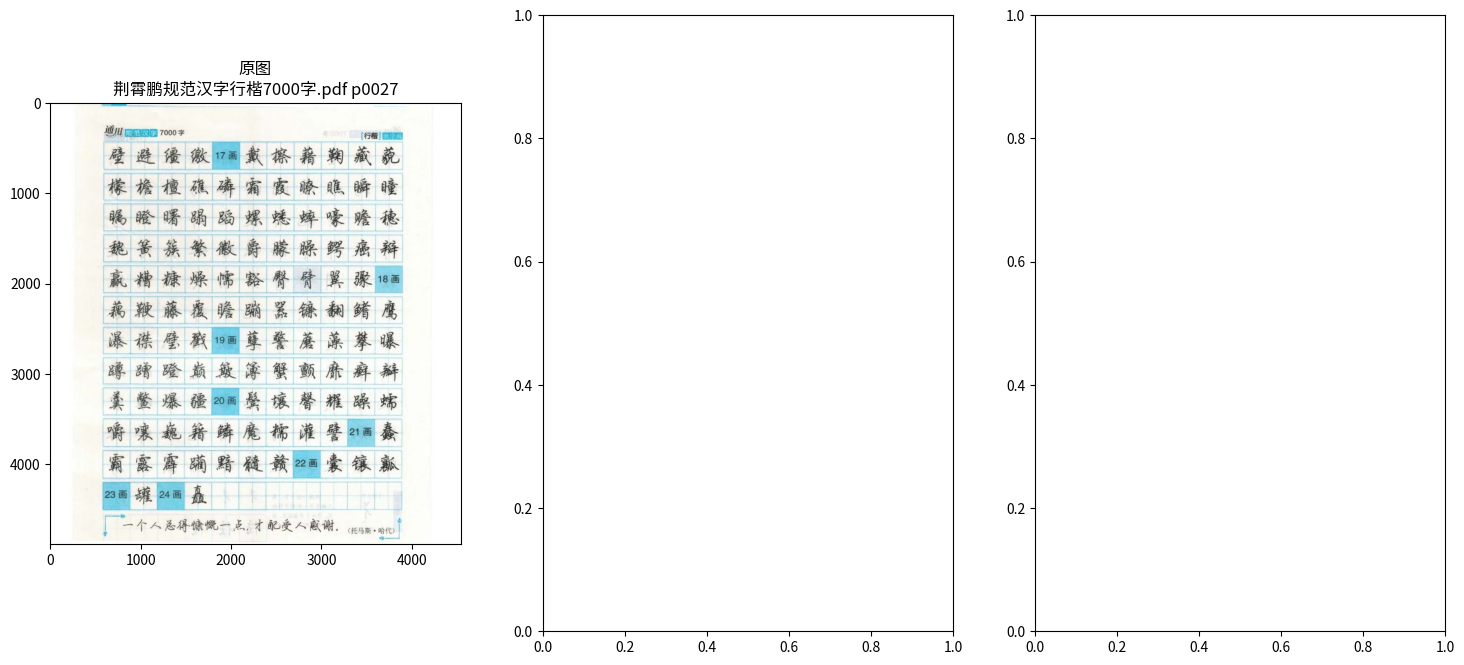

In [10]:

# =============================
# 指定 PDF 的指定单页：渲染 + 识别 + 保存 overlay
# =============================
from pathlib import Path
import gc
import cv2
import numpy as np
import pandas as pd
import math

# ---------- 可调参数 ----------
PDF_DPI = 300
DO_DESKEW = True
SAVE_OVERLAY = True

# 手动模式：
#   all / half_auto / half_even / half_odd / interleaved_phase
VERTICAL_MODE = "all"

# 指定 PDF 与页码（页码从 1 开始）
CWD = Path.cwd().resolve()
PROJECT_ROOT = CWD.parent if CWD.name == "scripts" else CWD

formal_candidates = [
    PROJECT_ROOT / "formal",
    CWD / "formal",
    PROJECT_ROOT.parent / "formal",
]
FORMAL_DIR = next((p for p in formal_candidates if p.exists() and p.is_dir()), PROJECT_ROOT / "formal")

# 方式 1：直接指定 PDF 文件名（推荐）
PDF_NAME = "荆霄鹏规范汉字行楷7000字.pdf"   # 例如 "荆霄鹏规范汉字行楷7000字.pdf"

# 方式 2：若 PDF_NAME=None，则使用索引
PDF_INDEX = 0

# 指定要处理的页码（1-based）
PAGE_NO = 27

OUTPUT_DIR = PROJECT_ROOT / "output"
TMP_IMG_DIR = OUTPUT_DIR / "_single_pdf_page_tmp"
OVERLAY_DIR = OUTPUT_DIR / "single_pdf_page_overlay"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
TMP_IMG_DIR.mkdir(parents=True, exist_ok=True)
OVERLAY_DIR.mkdir(parents=True, exist_ok=True)

print(f"[INFO] CWD={CWD}")
print(f"[INFO] PROJECT_ROOT={PROJECT_ROOT}")
print(f"[INFO] FORMAL_DIR={FORMAL_DIR}")
print(f"[INFO] OUTPUT_DIR={OUTPUT_DIR}")

# ---------- PDF 渲染工具 ----------
def get_pdf_page_count(pdf_path):
    try:
        import fitz
        with fitz.open(str(pdf_path)) as doc:
            return int(len(doc))
    except Exception:
        pass

    try:
        from pdf2image import pdfinfo_from_path
        info = pdfinfo_from_path(str(pdf_path))
        return int(info.get("Pages", 0))
    except Exception:
        return None

def render_one_pdf_page_to_bgr(pdf_path, page_no_1based, dpi=300):
    """
    渲染指定 PDF 的指定页，返回 BGR ndarray。
    """
    # 1) 优先 PyMuPDF
    try:
        import fitz
        with fitz.open(str(pdf_path)) as doc:
            idx = int(page_no_1based) - 1
            if idx < 0 or idx >= len(doc):
                raise IndexError(f"页码越界: page_no={page_no_1based}, total={len(doc)}")
            zoom = float(dpi) / 72.0
            mat = fitz.Matrix(zoom, zoom)
            page = doc[idx]
            pix = page.get_pixmap(matrix=mat, alpha=False)
            arr = np.frombuffer(pix.samples, dtype=np.uint8).reshape(pix.height, pix.width, pix.n)
            if pix.n == 1:
                bgr = cv2.cvtColor(arr, cv2.COLOR_GRAY2BGR)
            elif pix.n == 3:
                bgr = cv2.cvtColor(arr, cv2.COLOR_RGB2BGR)
            else:
                bgr = cv2.cvtColor(arr, cv2.COLOR_RGBA2BGR)
            return bgr
    except Exception:
        pass

    # 2) 回退 pdf2image
    from pdf2image import convert_from_path
    pil_list = convert_from_path(
        str(pdf_path),
        dpi=dpi,
        first_page=page_no_1based,
        last_page=page_no_1based,
    )
    if len(pil_list) == 0:
        raise RuntimeError(f"无法渲染页面: {pdf_path.name} p{page_no_1based}")
    pil_img = pil_list[0]
    rgb = np.array(pil_img.convert("RGB"))
    bgr = cv2.cvtColor(rgb, cv2.COLOR_RGB2BGR)
    return bgr

# ---------- 选择 PDF ----------
pdf_paths = sorted([p for p in FORMAL_DIR.rglob("*") if p.is_file() and p.suffix.lower() == ".pdf"])
if len(pdf_paths) == 0:
    raise RuntimeError(f"未在 {FORMAL_DIR} 下找到 PDF 文件")

if PDF_NAME is not None:
    matches = [p for p in pdf_paths if p.name == PDF_NAME]
    if len(matches) == 0:
        raise FileNotFoundError(f"未找到 PDF_NAME={PDF_NAME}")
    pdf_path = matches[0]
else:
    if PDF_INDEX < 0 or PDF_INDEX >= len(pdf_paths):
        raise IndexError(f"PDF_INDEX 越界: {PDF_INDEX}, total={len(pdf_paths)}")
    pdf_path = pdf_paths[PDF_INDEX]

page_total = get_pdf_page_count(pdf_path)
if page_total is not None and not (1 <= PAGE_NO <= page_total):
    raise IndexError(f"PAGE_NO 越界: {PAGE_NO}, total={page_total}")

print(f"[INFO] 选择 PDF: {pdf_path}")
print(f"[INFO] 总页数: {page_total}")
print(f"[INFO] 处理页码: p{PAGE_NO:04d}")

# ---------- 渲染指定页 ----------
page_bgr = render_one_pdf_page_to_bgr(pdf_path, PAGE_NO, dpi=PDF_DPI)
tmp_img_path = TMP_IMG_DIR / f"{pdf_path.stem}_p{PAGE_NO:04d}.png"
cv2.imwrite(str(tmp_img_path), page_bgr)

print(f"[INFO] 已渲染到临时页图: {tmp_img_path}")

# ---------- 调用单页主流程 ----------
res = process_one_page_exact(
    tmp_img_path,
    vertical_mode=VERTICAL_MODE,
    do_deskew=DO_DESKEW,
    show=False,
)

overlay_rgb = res["overlay"]
overlay_path = OVERLAY_DIR / f"{pdf_path.stem}_p{PAGE_NO:04d}_overlay.png"
if SAVE_OVERLAY:
    cv2.imwrite(str(overlay_path), cv2.cvtColor(overlay_rgb, cv2.COLOR_RGB2BGR))

single_page_df = pd.DataFrame([{
    "pdf_path": str(pdf_path),
    "pdf_name": pdf_path.name,
    "page": PAGE_NO,
    "temp_image": str(tmp_img_path.relative_to(PROJECT_ROOT)),
    "angle": float(res["angle"]),
    "h_lines": int(len(res["row_peaks"])),
    "v_lines": int(len(res["col_peaks"])),
    "raw_vertical_count": int(res.get("raw_vertical_count", len(res["col_peaks"]))),
    "chosen_vertical_mode": VERTICAL_MODE,
    "roi_box": str(res["roi_box"]),
}])

display(single_page_df)

fig, axes = plt.subplots(1, 3, figsize=(18, 8))
axes[0].imshow(res["img_rgb"])
axes[0].set_title(f"原图\n{pdf_path.name} p{PAGE_NO:04d}")
axes[1].imshow(res["grid_line_mask"], cmap="gray")
axes[1].set_title(f"grid_line_mask\nH={len(res['row_peaks'])}, V={len(res['col_peaks'])}")
axes[2].imshow(overlay_rgb)
axes[2].set_title(f"overlay\nangle={res['angle']:.2f}, mode={VERTICAL_MODE}")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()


In [ ]:

# =============================
# 根据当前单页识别到的横线和竖线，将该页分割为一个个方块图片并保存
# 说明：
# - 将 row_peaks / col_peaks 视为格子中心线
# - 采用相邻峰中点构造分割边界
# - 若检测到 H 条横峰、V 条竖峰，则输出 H × V 个图片
#   例如 H=12, V=12，则输出 144 个图片
# =============================
from pathlib import Path
import numpy as np
import cv2
import pandas as pd

CELL_OUTPUT_DIR = OUTPUT_DIR / "single_pdf_page_cells"
CELL_INDEX_CSV = OUTPUT_DIR / "single_pdf_page_cells_index.csv"
SAVE_CELL_DEBUG_OVERLAY = True

CELL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def centers_to_edges(peaks, lo_bound, hi_bound):
    peaks = np.asarray(sorted(set(int(p) for p in peaks)), dtype=np.float32)
    if len(peaks) == 0:
        return np.array([int(lo_bound), int(hi_bound)], dtype=int)
    if len(peaks) == 1:
        return np.array([int(lo_bound), int(hi_bound)], dtype=int)

    mids = (peaks[:-1] + peaks[1:]) / 2.0
    first_gap = peaks[1] - peaks[0]
    last_gap = peaks[-1] - peaks[-2]

    first_edge = peaks[0] - first_gap / 2.0
    last_edge = peaks[-1] + last_gap / 2.0

    edges = np.concatenate([[first_edge], mids, [last_edge]])
    edges = np.clip(edges, lo_bound, hi_bound)
    edges = np.round(edges).astype(int)

    for i in range(1, len(edges)):
        if edges[i] < edges[i - 1]:
            edges[i] = edges[i - 1]
    return edges

def draw_cell_boxes(img_rgb, x_edges, y_edges, color=(0, 255, 0), thickness=1):
    vis = img_rgb.copy()
    for r in range(len(y_edges) - 1):
        for c in range(len(x_edges) - 1):
            x0, x1 = int(x_edges[c]), int(x_edges[c + 1])
            y0, y1 = int(y_edges[r]), int(y_edges[r + 1])
            if x1 > x0 and y1 > y0:
                cv2.rectangle(vis, (x0, y0), (x1, y1), color, thickness)
    return vis

img_rgb = res["img_rgb"]
H_IMG, W_IMG = img_rgb.shape[:2]
x0_roi, x1_roi, y0_roi, y1_roi = res["roi_box"]
row_peaks = np.asarray(res["row_peaks"], dtype=int)
col_peaks = np.asarray(res["col_peaks"], dtype=int)

if len(row_peaks) == 0 or len(col_peaks) == 0:
    raise RuntimeError("当前单页缺少 row_peaks 或 col_peaks，无法切分")

y_edges = centers_to_edges(row_peaks, y0_roi, y1_roi)
x_edges = centers_to_edges(col_peaks, x0_roi, x1_roi)

page_dir = CELL_OUTPUT_DIR / pdf_path.stem / f"page_{PAGE_NO:04d}"
page_dir.mkdir(parents=True, exist_ok=True)

cell_records = []
saved_count = 0

for r in range(len(y_edges) - 1):
    for c in range(len(x_edges) - 1):
        x0 = int(x_edges[c]); x1 = int(x_edges[c + 1])
        y0 = int(y_edges[r]); y1 = int(y_edges[r + 1])

        x0 = max(0, min(x0, W_IMG - 1))
        x1 = max(0, min(x1, W_IMG))
        y0 = max(0, min(y0, H_IMG - 1))
        y1 = max(0, min(y1, H_IMG))

        if x1 <= x0 or y1 <= y0:
            continue

        crop = img_rgb[y0:y1, x0:x1]
        out_name = f"r{r+1:02d}_c{c+1:02d}.png"
        out_path = page_dir / out_name
        cv2.imwrite(str(out_path), cv2.cvtColor(crop, cv2.COLOR_RGB2BGR))

        cell_records.append({
            "pdf_path": str(pdf_path),
            "pdf_name": pdf_path.name,
            "page": int(PAGE_NO),
            "chosen_vertical_mode": VERTICAL_MODE,
            "row_count": int(len(row_peaks)),
            "col_count": int(len(col_peaks)),
            "cell_row": int(r + 1),
            "cell_col": int(c + 1),
            "x0": int(x0),
            "x1": int(x1),
            "y0": int(y0),
            "y1": int(y1),
            "cell_path": str(out_path.relative_to(PROJECT_ROOT)),
        })
        saved_count += 1

cells_df = pd.DataFrame(cell_records)
cells_df.to_csv(CELL_INDEX_CSV, index=False, encoding="utf-8-sig")

print("\n========== 单页方块切分完成 ==========")
print(f"PDF: {pdf_path.name}")
print(f"Page: p{PAGE_NO:04d}")
print(f"H={len(row_peaks)}, V={len(col_peaks)}")
print(f"保存方块数: {saved_count}")
print(f"方块输出目录: {page_dir}")
print(f"索引 CSV: {CELL_INDEX_CSV}")

if SAVE_CELL_DEBUG_OVERLAY:
    debug_vis = draw_cell_boxes(img_rgb, x_edges, y_edges, color=(0, 255, 0), thickness=1)
    debug_path = page_dir / "_grid_boxes_overlay.png"
    cv2.imwrite(str(debug_path), cv2.cvtColor(debug_vis, cv2.COLOR_RGB2BGR))

    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    axes[0].imshow(res["overlay"])
    axes[0].set_title("识别结果 overlay")
    axes[1].imshow(debug_vis)
    axes[1].set_title(f"切分边界 overlay\ncells={saved_count}")
    for ax in axes:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

display(cells_df.head(20))
